<a href="https://colab.research.google.com/github/logyfarg/ecg-cnn-smote-shap/blob/main/heart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install kagglehub tensorflow scikit-learn imbalanced-learn shap matplotlib seaborn

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shayanfazeli/heartbeat")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'heartbeat' dataset.
Path to dataset files: /kaggle/input/heartbeat


Using Colab cache for faster access to the 'heartbeat' dataset.
Dataset path: /kaggle/input/heartbeat
Train shape: (87554, 188)
Test  shape: (21892, 188)

Train class distribution (binary):
0    72471
1    15083
Name: count, dtype: int64

Test  class distribution (binary):
0    18118
1     3774
Name: count, dtype: int64

Applying SMOTE …
After SMOTE: {0: 72471, 1: 72471}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 187, 32)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 93, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 93, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 93, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 46, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 46, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 46, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 23, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 23, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2944)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       376,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 408,129 (1.56 MB)

 Trainable params: 408,129 (1.56 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1925/1925 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 0.8969 - auc: 0.9549 - loss: 0.2562 - precision: 0.9059 - recall: 0.8365 - val_accuracy: 0.9278 - val_auc: 0.0000e+00 - val_loss: 0.1574 - val_precision: 1.0000 - val_recall: 0.9278 - learning_rate: 0.0010
Epoch 2/30
1925/1925 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9379 - auc: 0.9792 - loss: 0.1661 - precision: 0.9487 - recall: 0.8979 - val_accuracy: 0.9251 - val_auc: 0.0000e+00 - val_loss: 0.1593 - val_precision: 1.0000 - val_recall: 0.9251 - learning_rate: 0.0010
Epoch 3/30
1925/1925 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9490 - auc: 0.9853 - loss: 0.1389 - precision: 0.9583 - recall: 0.9159 - val_accuracy: 0.9477 - val_auc: 0.0000e+00 - val_loss: 0.1131 - val_precision: 1.0000 - val_recall: 0.9477 - learning_rate: 0.0010
Epoch 4/30
1925/1925 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9553 - auc: 0.9883 - loss: 0.1229 - precision: 0.9627 - recall: 0.9275 - val_accuracy: 0.9631 - val_auc: 0.0000e+

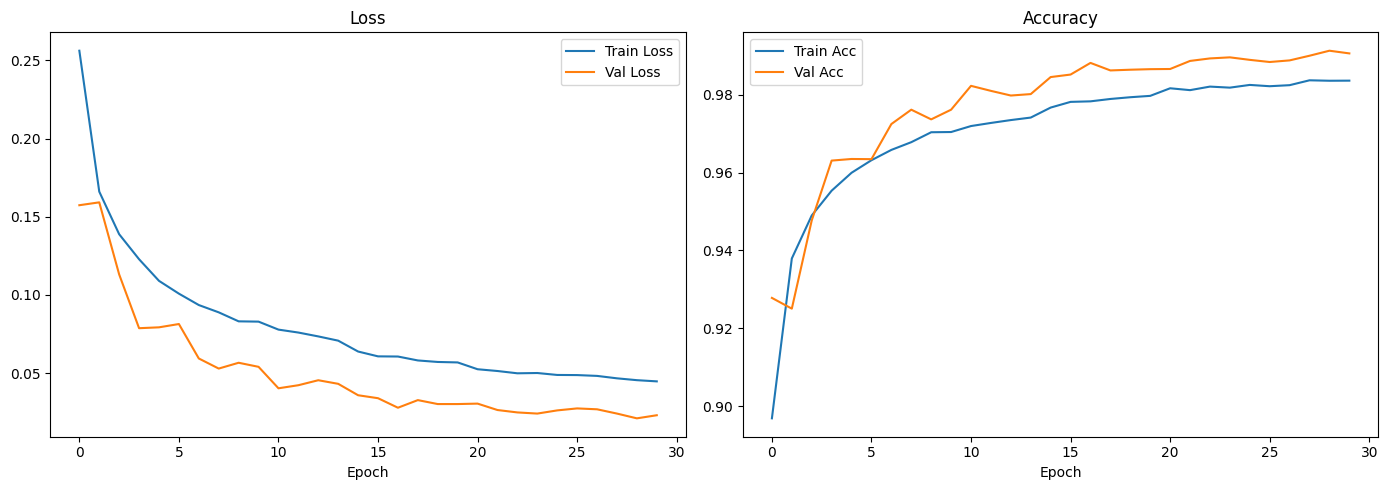

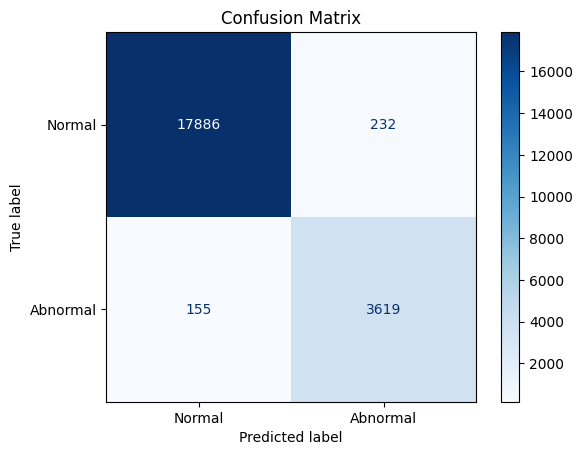

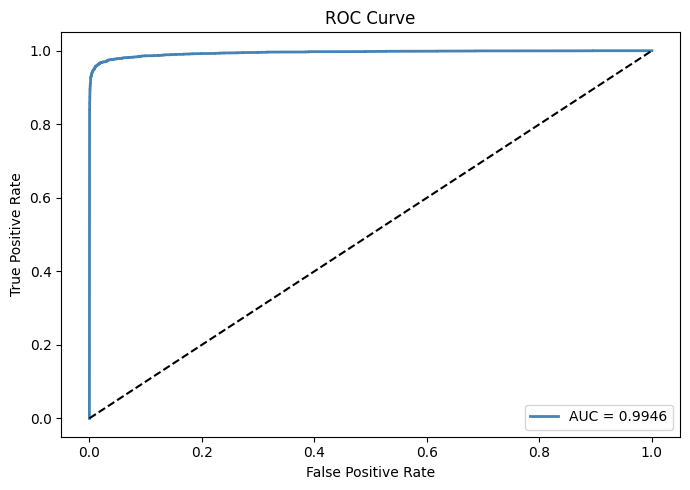


Computing SHAP values (this may take a few minutes) …


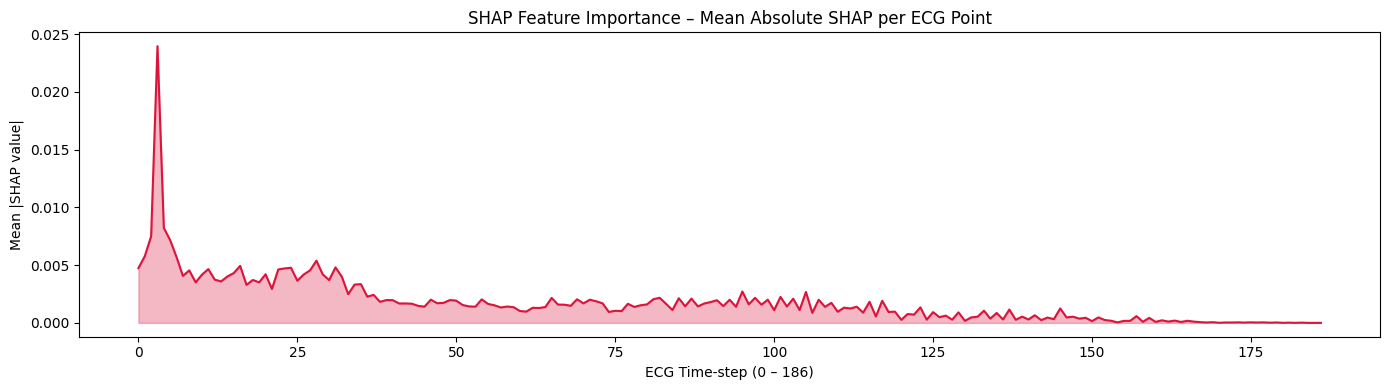

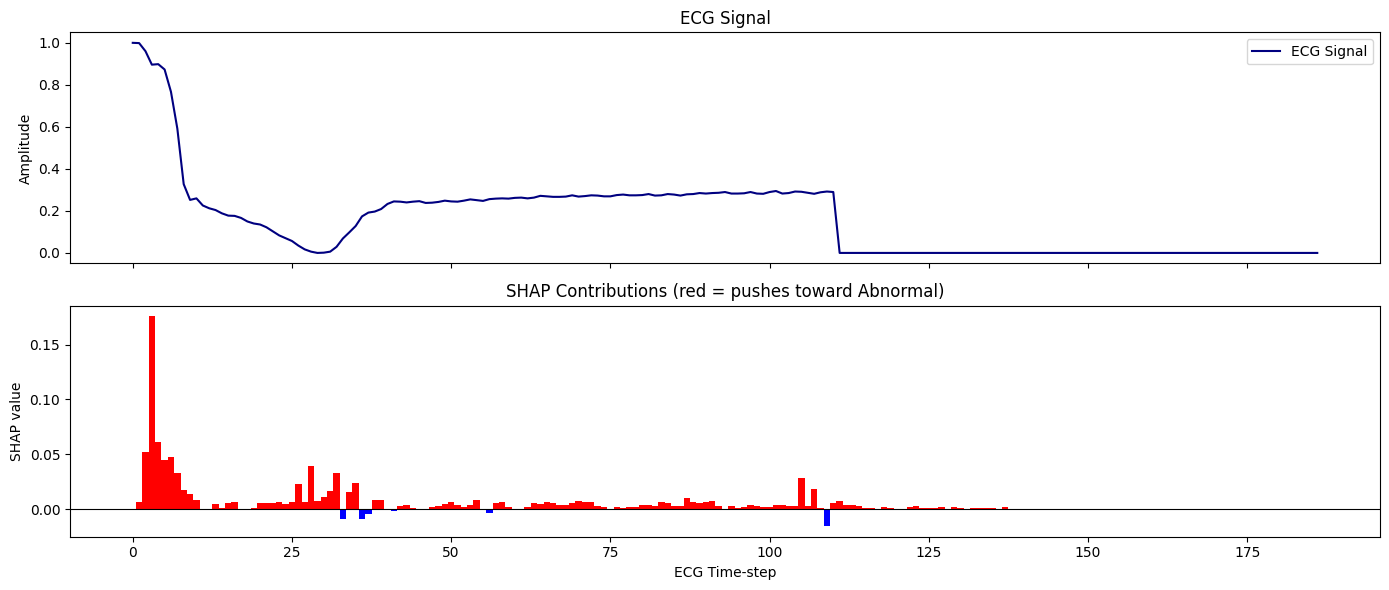


✅ Pipeline complete. Figures saved to working directory.


In [1]:
# ============================================================
# ECG-Based Heart Disease Detection
# 1D-CNN + SMOTE + SHAP Explainability
# MIT-BIH Arrhythmia Dataset
# ============================================================

# ── 0. Install / Download ────────────────────────────────────
import kagglehub
path = kagglehub.dataset_download("shayanfazeli/heartbeat")
print("Dataset path:", path)

# ── 1. Imports ───────────────────────────────────────────────
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, Dropout,
                                     Flatten, Dense)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import shap

warnings.filterwarnings("ignore")
tf.random.set_seed(42)
np.random.seed(42)

# ── 2. Load Dataset ──────────────────────────────────────────
train_path = os.path.join(path, "mitbih_train.csv")
test_path  = os.path.join(path, "mitbih_test.csv")

train_df = pd.read_csv(train_path, header=None)
test_df  = pd.read_csv(test_path,  header=None)

print(f"Train shape: {train_df.shape}")
print(f"Test  shape: {test_df.shape}")

# ── 3. Split Features & Labels ───────────────────────────────
X_train_raw = train_df.iloc[:, :-1].values   # 187 ECG points
y_train_raw = train_df.iloc[:,  -1].values

X_test_raw  = test_df.iloc[:, :-1].values
y_test_raw  = test_df.iloc[:,  -1].values

# ── 4. Binary Conversion (0 = normal, 1 = abnormal) ──────────
y_train = (y_train_raw != 0).astype(int)
y_test  = (y_test_raw  != 0).astype(int)

print(f"\nTrain class distribution (binary):\n{pd.Series(y_train).value_counts()}")
print(f"\nTest  class distribution (binary):\n{pd.Series(y_test).value_counts()}")

# ── 5. Min-Max Normalisation ─────────────────────────────────
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)

# ── 6. SMOTE – Handle Class Imbalance ────────────────────────
print("\nApplying SMOTE …")
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)
print(f"After SMOTE: {pd.Series(y_train_res).value_counts().to_dict()}")

# ── 7. Reshape for 1D-CNN  (samples, timesteps, channels) ────
X_train_cnn = X_train_res.reshape(-1, 187, 1)
X_test_cnn  = X_test_scaled.reshape(-1, 187, 1)

# ── 8. Build 1D-CNN Model ────────────────────────────────────
def build_model(input_shape=(187, 1)):
    model = Sequential([
        # Block 1
        Conv1D(32, kernel_size=3, activation="relu", padding="same",
               input_shape=input_shape),
        MaxPooling1D(pool_size=2),
        Dropout(0.5),

        # Block 2
        Conv1D(64, kernel_size=3, activation="relu", padding="same"),
        MaxPooling1D(pool_size=2),
        Dropout(0.5),

        # Block 3
        Conv1D(128, kernel_size=3, activation="relu", padding="same"),
        MaxPooling1D(pool_size=2),
        Dropout(0.5),

        # Classifier head
        Flatten(),
        Dense(128, activation="relu"),
        Dense(1,   activation="sigmoid"),
    ])
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy",
                 tf.keras.metrics.AUC(name="auc"),
                 tf.keras.metrics.Precision(name="precision"),
                 tf.keras.metrics.Recall(name="recall")],
    )
    return model

model = build_model()
model.summary()

# ── 9. Callbacks ─────────────────────────────────────────────
callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1),
]

# ── 10. Train ────────────────────────────────────────────────
history = model.fit(
    X_train_cnn, y_train_res,
    epochs=30,
    batch_size=64,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1,
)

# ── 11. Evaluate on Test Set ─────────────────────────────────
y_prob = model.predict(X_test_cnn).flatten()
y_pred = (y_prob >= 0.5).astype(int)

print("\n── Classification Report ──")
print(classification_report(y_test, y_pred,
                             target_names=["Normal (0)", "Abnormal (1)"]))

auc = roc_auc_score(y_test, y_prob)
print(f"AUC-ROC: {auc:.4f}")

# ── 12. Plot Training Curves ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["loss"],     label="Train Loss")
axes[0].plot(history.history["val_loss"], label="Val Loss")
axes[0].set_title("Loss"); axes[0].legend(); axes[0].set_xlabel("Epoch")

axes[1].plot(history.history["accuracy"],     label="Train Acc")
axes[1].plot(history.history["val_accuracy"], label="Val Acc")
axes[1].set_title("Accuracy"); axes[1].legend(); axes[1].set_xlabel("Epoch")

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

# ── 13. Confusion Matrix ─────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Normal", "Abnormal"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

# ── 14. ROC Curve ────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="steelblue", lw=2, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(); plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150)
plt.show()

# ── 15. SHAP Explainability ───────────────────────────────────
print("\nComputing SHAP values (this may take a few minutes) …")

# Use a small background set for efficiency
background = X_train_cnn[:200]
explainer  = shap.DeepExplainer(model, background)

# Explain a sample of test instances
sample_idx  = np.random.choice(len(X_test_cnn), size=100, replace=False)
X_explain   = X_test_cnn[sample_idx]
shap_values = explainer.shap_values(X_explain)

# shap_values shape: (n_samples, 187, 1) → squeeze channel dim
sv = np.array(shap_values).squeeze()   # (100, 187)

# ── Mean absolute SHAP per ECG time-step ─────────────────────
mean_abs_shap = np.abs(sv).mean(axis=0)   # (187,)

plt.figure(figsize=(14, 4))
plt.plot(mean_abs_shap, color="crimson", lw=1.5)
plt.fill_between(range(187), mean_abs_shap, alpha=0.3, color="crimson")
plt.xlabel("ECG Time-step (0 – 186)")
plt.ylabel("Mean |SHAP value|")
plt.title("SHAP Feature Importance – Mean Absolute SHAP per ECG Point")
plt.tight_layout()
plt.savefig("shap_importance.png", dpi=150)
plt.show()

# ── SHAP for a single abnormal prediction ────────────────────
# Find a likely abnormal sample
abnormal_mask = y_pred[sample_idx] == 1
if abnormal_mask.any():
    idx_local = np.where(abnormal_mask)[0][0]
else:
    idx_local = 0

ecg_signal = X_explain[idx_local].squeeze()     # (187,)
shap_sig   = sv[idx_local]                       # (187,)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax1.plot(ecg_signal, color="navy", lw=1.5, label="ECG Signal")
ax1.set_ylabel("Amplitude"); ax1.legend()
ax1.set_title("ECG Signal")

colors = ["red" if v > 0 else "blue" for v in shap_sig]
ax2.bar(range(187), shap_sig, color=colors, width=1.0)
ax2.axhline(0, color="black", lw=0.8)
ax2.set_xlabel("ECG Time-step")
ax2.set_ylabel("SHAP value")
ax2.set_title("SHAP Contributions (red = pushes toward Abnormal)")

plt.tight_layout()
plt.savefig("shap_single_prediction.png", dpi=150)
plt.show()

print("\n✅ Pipeline complete. Figures saved to working directory.")